## **Data Cleaning for Lipid Residue analysis on pottery residuals of Indus Valley Civilisation**

### Importing the necessary libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from collections import Counter
from sklearn import tree
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import KFold, cross_val_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_validate





### Loading and visualizing the dataset

In [2]:
df = pd.read_csv('./data.csv')
df

,Site_name,Sample,Rural_urban,Trench_Context,Context_Notes,Chronology,Before_After_4.2_kya,Chronology_details,Artefact_type,Rim_base_body,...,dilution_ul,qty_C16_inj_ng,qty_C18_inj_ng,PS_ratio,C12_C14,C161_C181,C15_C17_C18,delta13C_C16,delta13C_C18,bigdelta
0,ALM,ALM114-252,Rural,SC-114,114,Late_Harappan,Post 4.2 ka,LH,potsherd,rim,...,NaN,NaN,NaN,2.358959,NaN,0.347380743,0.378502977,-28.96,-28.71,0.25
1,ALM,ALM117-275,Rural,SC-117,117,Late_Harappan,Post 4.2 ka,LH,potsherd,rim,...,NaN,NaN,NaN,1.818993,NaN,0.485352045,0.254884101,-29.01,-29.03,-0.02
2,ALM,ALM117-276,Rural,SC-117,117,Late_Harappan,Post 4.2 ka,LH,potsherd,rim,...,NaN,NaN,NaN,1.153828,NaN,0.381344716,0.08502217,NaN,NaN,NaN
3,ALM,ALM117-279,Rural,SC-117,117,Late_Harappan,Post 4.2 ka,LH,potsherd,rim,...,NaN,NaN,NaN,1.486213,NaN,0.568954957,0.167131509,-28.85,-29.39,-0.54
4,ALM,ALM119-363,Rural,SC-119,119,Late_Harappan,During,LH,potsherd,rim,...,NaN,NaN,NaN,1.091906,NaN,#VALUE!,#VALUE!,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,RGR,RGR027,Urban,4.1F-14038,14038,Mature_Harappan,Pre 4.2 ka,MHi-ii,potsherd,rim,...,NaN,NaN,NaN,1.147915,NaN,0.367643525,0.101684656,NaN,NaN,NaN
120,RGR,RGR029,Urban,4.1E-14004,14004,Mature_Harappan,Pre 4.2 ka,MHi-ii,potsherd,neck,...,NaN,NaN,NaN,1.170085,NaN,0.488663074,0.073159257,-28.86,-28.97,-0.11
121,RGR,RGR030,Urban,4.1E-14005,14005,Mature_Harappan,Pre 4.2 ka,MHi-ii,potsherd,body,...,NaN,NaN,NaN,0.999672,NaN,#VALUE!,#VALUE!,NaN,NaN,NaN
122,Tamil Nadu cow milk,Cow milk,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-27.50,-32.10,-4.60


In [3]:
df.shape

(124, 89)

# Data cleaning

### Listing out the features in the dataset

In [4]:
def getFeatureNames(dataFrame):
    allfeatures=[]
    for feature in dataFrame.columns:
        allfeatures.append(feature)
    return allfeatures

allfeatures= getFeatureNames(df)
print('These are the features in the dataset: \n\n',allfeatures)

These are the features in the dataset: 

 ['Site_name', 'Sample', 'Rural_urban', 'Trench_Context', 'Context_Notes', 'Chronology', 'Before_After_4.2_kya', 'Chronology_details', 'Artefact_type', 'Rim_base_body', 'Rim_diam_cm', 'Vesseltype', 'Vessel_form', 'Vessel_type', 'Vessel_category', 'Haryana_or_Classic', 'Saturated', 'Unsaturated', 'Branched', 'Date_of_analysis', 'Sample_mass_mg', 'Area_GC_total', 'AreaC12', 'AreaC14', 'AreaC15', 'AreaC161', 'AreaC16', 'AreaC17', 'AreaC181', 'AreaC18', 'AreaC19', 'AreaC201', 'AreaC20', 'AreaC21', 'AreaC221', 'AreaC22', 'AreaC23', 'AreaC24', 'AreaC25', 'AreaC26', 'AreaC28', 'Areaphthalates', 'FAMEarea', 'Area_IS_C36', 'Area_IS_C34', 'Mass_IS_C34_ug', 'Mass_IS_C36_ug', 'Lipidconc_ug_vial', 'Lipidconc_ug_g', 'Interpretable', 'C12concentration_ug_vial', 'C14concentration_ug_vial', 'C15concentration_ug_vial', 'C161concentration_ug_vial', 'C16concentration_ug_vial', 'C17concentration_ug_vial ', 'C181concentration_ug_vial', 'C18concentration_ug_vial', 'C1

## Feature Selection

### Among the categorical features, only those that are useful according to the paper are considered, while ignoring features that are apparently redundant when other already selected features are present.

In [5]:
myCategoricalFeaturesList = ['Cholesterol_derivatives', 'longchain_ Alkanes', 'Alcohols', 'Sulphur','Branched']   


### Checking Number of NaN values in the chosen Categorical Features

In [6]:
for feature in myCategoricalFeaturesList:
    nan_count = df[feature].isna().sum()
    non_nan_count = df[feature].notna().sum()
    

    print(f"\nFeature: {feature}")
    print("NaN count     :", nan_count)
    print("Non NaN count :", non_nan_count)
    


Feature: Cholesterol_derivatives
NaN count     : 3
Non NaN count : 121

Feature: longchain_ Alkanes
NaN count     : 3
Non NaN count : 121

Feature: Alcohols
NaN count     : 2
Non NaN count : 122

Feature: Sulphur
NaN count     : 3
Non NaN count : 121

Feature: Branched
NaN count     : 58
Non NaN count : 66


### Selecting a final categorical list after leaving the feature 'Branched' with too many NaN values

In [7]:
myCategoricalFeaturesList = ['Cholesterol_derivatives', 'longchain_ Alkanes', 'Alcohols', 'Sulphur']   

### Considering all the important numerical features identified in the paper.

In [8]:
#These describe the chain-length distribution of fatty acids, which reflects:Animal fats,Plant waxes, Aquatic or microbial inputs

myNumericalFeaturesList = ['C12concentration_ug_vial', 'C14concentration_ug_vial',     
       'C15concentration_ug_vial', 'C161concentration_ug_vial',
       'C16concentration_ug_vial', 'C17concentration_ug_vial ',
       'C181concentration_ug_vial', 'C18concentration_ug_vial',
       'C19concentration_ug_vial', 'C201concentration',
       'C20concentration_ug_vial', 'C21concentration_ug_vial',
       'C221concentration', 'C22concentration (ug/vial)',
       'C23concentration_ug_vial', 'C24concentration_ug_vial',
       'C25concentration_ugvial', 'C26concentration_ug_vial',
       'C28concentration_ug_vial', 'C34concentration_ug_vial', 'FAMEconcentration',
        'C16conc_ug_vial', 'C18conc_ug_vial' ,
        'C12_C14', 'C161_C181', 'C15_C17_C18','delta13C_C16','delta13C_C18','bigdelta','PS_ratio'
        ]

### Selecting numerical features based on a threshold number of valid feature values

The below function converts each feature in myFeaturesList to numeric values, coercing non-numeric entries to NaN.

It counts how many valid (non-NaN) numbers each feature contains and prints this information.

Features with a count of real numbers greater than or equal to thresholdNumReals are selected and returned as a list.

In [9]:

def reliableNumericalFeatureSelector(thresholdNumReals, myFeaturesList, DataFrame ):  
    
    selectedFeatureNames = []
    for i in range(len(myFeaturesList)): 

        selectedColumnForTesting = myFeaturesList[i]

        DataFrame[selectedColumnForTesting] = pd.to_numeric(DataFrame[selectedColumnForTesting], errors='coerce')

        totalRealNums = DataFrame[selectedColumnForTesting].notna().sum().item()   #checking total number of real numbers in each feature
        
        print("For the feature : ", selectedColumnForTesting)
        print("Total of real numbers in the feature", totalRealNums)      # 
        print()

        if totalRealNums>=thresholdNumReals:
            selectedFeatureNames.append(selectedColumnForTesting)
    return selectedFeatureNames

### Setting the threshold value as 120 because the total number of samples is just 124 so that I am able have atleast 120 samples in the dataset which I consider for ML further

In [10]:

selectedNumericalFeatureNames = reliableNumericalFeatureSelector(120, myNumericalFeaturesList, df )

For the feature :  C12concentration_ug_vial
Total of real numbers in the feature 35

For the feature :  C14concentration_ug_vial
Total of real numbers in the feature 109

For the feature :  C15concentration_ug_vial
Total of real numbers in the feature 100

For the feature :  C161concentration_ug_vial
Total of real numbers in the feature 90

For the feature :  C16concentration_ug_vial
Total of real numbers in the feature 122

For the feature :  C17concentration_ug_vial 
Total of real numbers in the feature 91

For the feature :  C181concentration_ug_vial
Total of real numbers in the feature 115

For the feature :  C18concentration_ug_vial
Total of real numbers in the feature 122

For the feature :  C19concentration_ug_vial
Total of real numbers in the feature 18

For the feature :  C201concentration
Total of real numbers in the feature 16

For the feature :  C20concentration_ug_vial
Total of real numbers in the feature 74

For the feature :  C21concentration_ug_vial
Total of real number

### Printing the selected numerical features. A total 7 numerical features which contain valid numerical values were selcted by the function reliableNumericalFeatureSelector given threshold 120

In [11]:
print("How many numerical features are selected ? :", len(selectedNumericalFeatureNames))
print('')
print("what are the numerical features selected based on quality of values \n", selectedNumericalFeatureNames)


How many numerical features are selected ? : 7

what are the numerical features selected based on quality of values 
 ['C16concentration_ug_vial', 'C18concentration_ug_vial', 'C34concentration_ug_vial', 'FAMEconcentration', 'C16conc_ug_vial', 'C18conc_ug_vial', 'PS_ratio']


### Visualizing the filterd dataframe

In [12]:
FinalListOfFeatures = selectedNumericalFeatureNames + myCategoricalFeaturesList
df[FinalListOfFeatures]

,C16concentration_ug_vial,C18concentration_ug_vial,C34concentration_ug_vial,FAMEconcentration,C16conc_ug_vial,C18conc_ug_vial,PS_ratio,Cholesterol_derivatives,longchain_ Alkanes,Alcohols,Sulphur
0,5.276055,2.236603,6.380712,1.584887,5.276055,2.236603,2.358959,Absent,Absent,Absent,Absent
1,5.914593,3.251575,5.588366,2.051386,5.914593,3.251575,1.818993,Absent,Absent,Absent,Absent
2,3.682827,3.191835,6.139500,1.191840,3.682827,3.191835,1.153828,Absent,Absent,Absent,Absent
3,5.361691,3.607618,6.350696,1.615920,5.361691,3.607618,1.486213,Absent,Absent,Absent,Absent
4,3.975178,3.640587,4.422916,0.999234,3.975178,3.640587,1.091906,Absent,Absent,Absent,Absent
...,...,...,...,...,...,...,...,...,...,...,...
119,4.461765,3.886842,8.205607,1.596057,4.461765,3.886842,1.147915,Absent,Present,Absent,Absent
120,5.289429,4.520550,NaN,1.851363,5.289429,4.520550,1.170085,Absent,Present,Absent,Absent
121,2.617693,2.618553,7.454912,0.958529,2.617693,2.618553,0.999672,Absent,Absent,Absent,Absent
122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### COnverting up of Target labels to categorical evaluate clustering later on by processing the 'PS_ratio' column

In [13]:
#Setting up PS_Ratio as target
df['target'] = pd.NA

df.loc[df['PS_ratio'] < 1, 'target'] = 'd'                                #PS_ratio <1 is ruminant fats
df.loc[(df['PS_ratio'] >= 1) & (df['PS_ratio'] < 1.2), 'target'] = 'r'    #PS_ratio >1 is ruminant fats
df.loc[(df['PS_ratio'] >= 1.2) & (df['PS_ratio'] <= 2), 'target'] = 'nr'    #PS_ratio >1 is ruminant fats
df.loc[df['PS_ratio'] > 2, 'target'] = 'p'                                #PS_ratio <1 is ruminant fats

df['target'].value_counts()

target
nr    52
p     27
r     25
d     18
Name: count, dtype: int64

### Identifying the numerical features in the form of object datatype and converting it to numerical

In [14]:
FinalNumericalFrame = df[selectedNumericalFeatureNames]

for seletedFeature in selectedNumericalFeatureNames:                 
    print("column datatype", FinalNumericalFrame[seletedFeature].dtype)  
    if(FinalNumericalFrame[seletedFeature].dtype != 'float64'):
        FinalNumericalFrame[seletedFeature] = pd.to_numeric(
        FinalNumericalFrame[seletedFeature],
        errors='coerce' 
        )


column datatype float64
column datatype float64
column datatype float64
column datatype float64
column datatype float64
column datatype float64
column datatype float64


### Preparing Categorical Features for Analysis

This code selects the categorical columns specified in myCategoricalFeaturesList from the dataframe df. It then replaces the values 'Present' and 'Absent' with boolean True and False, respectively, and ensures all entries in the resulting dataframe are of boolean type for easier analysis.

In [15]:
FinalCategoricalFrame = df[myCategoricalFeaturesList]  # Selecting the chosen categorical columns

FinalCategoricalFrame = FinalCategoricalFrame.replace({     #Replacing Present by True and Absent by False
    'Present': True,
    'Absent': False
}).astype(bool)

### Combining categorical features, numerical features, and the PS_ratio (processed as the target), and dropping all NaN values to prepare the dataset for machine learning tasks.

In [16]:
FinalDataFrameForML=pd.concat(    
    [FinalNumericalFrame,FinalCategoricalFrame,df['target']],
    axis=1
).dropna()
FinalDataFrameForML


,C16concentration_ug_vial,C18concentration_ug_vial,C34concentration_ug_vial,FAMEconcentration,C16conc_ug_vial,C18conc_ug_vial,PS_ratio,Cholesterol_derivatives,longchain_ Alkanes,Alcohols,Sulphur,target
0,5.276055,2.236603,6.380712,1.584887,5.276055,2.236603,2.358959,False,False,False,False,p
1,5.914593,3.251575,5.588366,2.051386,5.914593,3.251575,1.818993,False,False,False,False,nr
2,3.682827,3.191835,6.139500,1.191840,3.682827,3.191835,1.153828,False,False,False,False,r
3,5.361691,3.607618,6.350696,1.615920,5.361691,3.607618,1.486213,False,False,False,False,nr
4,3.975178,3.640587,4.422916,0.999234,3.975178,3.640587,1.091906,False,False,False,False,r
...,...,...,...,...,...,...,...,...,...,...,...,...
116,2.389047,1.030552,7.277280,0.598009,2.389047,1.030552,2.318221,False,True,True,False,p
117,1.677165,2.096592,5.918140,3.466039,1.677165,2.096592,0.799948,False,True,False,False,d
118,1.949935,1.567359,8.427425,0.996347,1.949935,1.567359,1.244090,False,False,False,False,nr
119,4.461765,3.886842,8.205607,1.596057,4.461765,3.886842,1.147915,False,True,False,False,r


In [17]:
FinalDataFrameForML.shape

(121, 12)

### Correlation Analysis of features

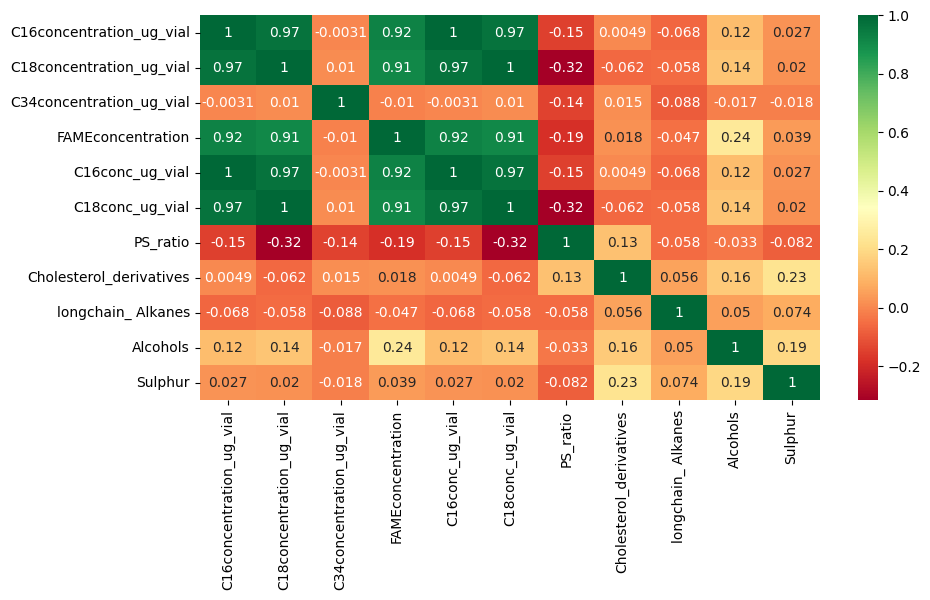

In [18]:
plt.figure(figsize=(10,5))

# Plot heat map
g=sns.heatmap(FinalDataFrameForML.drop(columns=['target']).corr(),annot=True,cmap="RdYlGn")

### Two pairs of features had correlation value =1, so one feature from each of the pairs were removed and plotted again

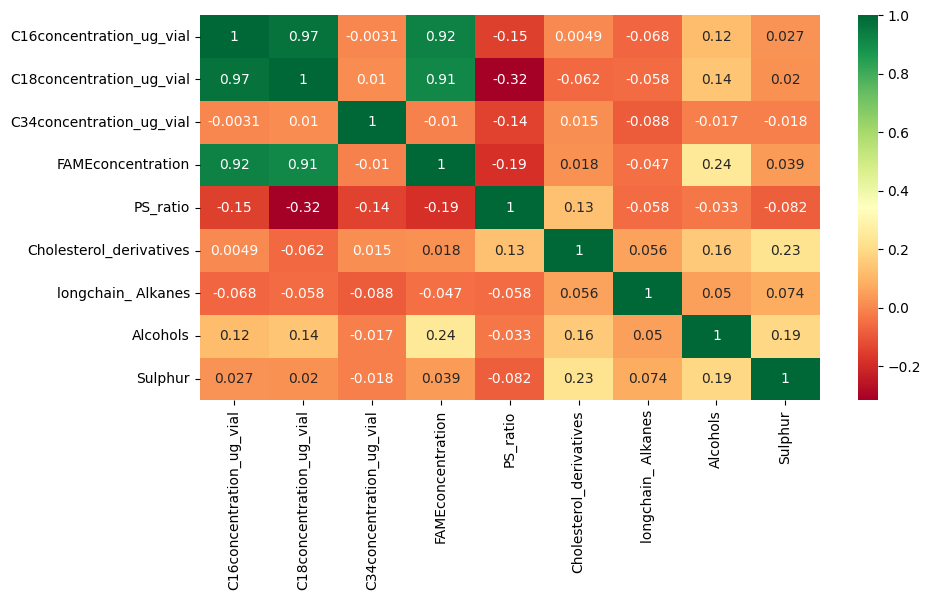

In [19]:
CorrelationRemovedDataFrame = FinalDataFrameForML.drop(
    columns=['C16conc_ug_vial','C18conc_ug_vial']   
)
plt.figure(figsize=(10,5))
g=sns.heatmap(CorrelationRemovedDataFrame.drop(columns=['target']).corr(),annot=True,cmap="RdYlGn")

# ML methdos

In [20]:
# set the y (the label we want to predict)
y = FinalDataFrameForML['PS_ratio']

# set the X (the features we want the algorithm to learn from)
X = FinalDataFrameForML.drop(columns=myCategoricalFeaturesList+['target', 'PS_ratio'])

In [21]:
X.shape, y.shape

((121, 6), (121,))

In [22]:

# Using sklearn to automatically make a test/train set from our data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

### SInce our target variable 'PS_ratio' is a continuous variable, we choose regression models 'RandomForestRegressor' and 'XGBRegressor' to predict PS_ratio

### Training of Random Forest Regressor

In [23]:
# Remember that the age (what we are trying to predict) is a continuous feature - therefore we need a Regressor
# It's only when we are predicting a categorical feature that we use a classifier

rf_reg = RandomForestRegressor(max_depth=3, random_state=0)  # There are lots of other hyperparametres we could play with

# Train Decision Tree Regressor on our data
rf_reg = rf_reg.fit(X_train,y_train)

### Predictions of RandomForestRegressor on test set

MAE: 0.2813713283445342
RMSE: 0.3934419699982459


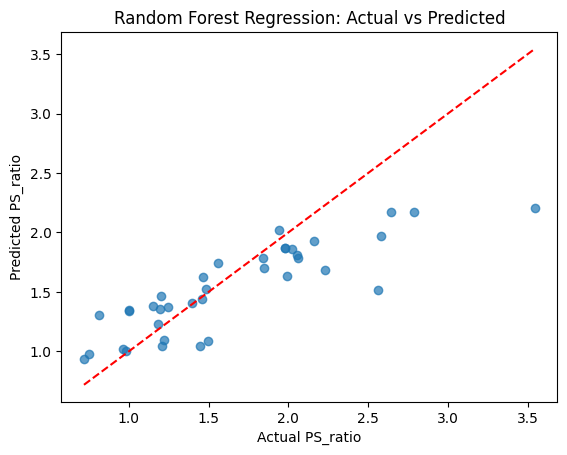

In an ideal case scenario, the points should lie on the red dotted 45 degree line/ Deviation of points from this line visually indicates how far are predicted values from actual values


In [24]:
y_pred = rf_reg.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual PS_ratio")
plt.ylabel("Predicted PS_ratio")
plt.title("Random Forest Regression: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 45-degree line
plt.show()
print("In an ideal case scenario, the points should lie on the red dotted 45 degree line/ Deviation of points from this line visually indicates how far are predicted values from actual values")

### K-fold cross validation on RandomForestRegressor including wthe whole dataset 

In [25]:
# choosing how many parts (folds) to split the data into
# Here, we use 5 parts
k = 5
#Setting up K-Fold cross-validation. The data is split into 5 parts. shuffle=True mixes the data before splitting. random_state=0 makes the result reproducible
kf = KFold(n_splits=k, shuffle=True, random_state=0)

# How we want to measure how good the model is
scoring = {"mae": "neg_mean_absolute_error", "rmse": "neg_root_mean_squared_error", }

# Run cross-validation. The model is trained 5 times. Each time, a different part of the data is used for testing
cv = cross_validate( rf_reg, X, y, cv=kf, scoring=scoring, return_train_score=False )

print("k-Fold CV Results (mean ± std)")
print("MAE: ", (-cv["test_mae"]).mean(), "±", (-cv["test_mae"]).std())
print("RMSE:", (-cv["test_rmse"]).mean(), "±", (-cv["test_rmse"]).std())

#On average, the model’s predictions are about 0.29 away from the real values.
# Sometimes it makes large errors indicated by RMSE is higher at about 0.39.
#The results are fairly consistent across the 5 data splits.

k-Fold CV Results (mean ± std)
MAE:  0.291468933331974 ± 0.0613460146888071
RMSE: 0.3904561348914686 ± 0.07226055187237215


### Importance scores of Features by RandomForestRegressor

In [26]:
# Mean Decrease in Impurity (MDI)

importances = rf_reg.feature_importances_

feature_names = X.columns

sorted_idx = np.argsort(importances)[::-1]  # This arranges the features in order of importance

# Now we can print them
for i in sorted_idx:

    print(f"{feature_names[i]}: {importances[i]:.3f}")

C18concentration_ug_vial: 0.316
C18conc_ug_vial: 0.289
C16concentration_ug_vial: 0.195
C16conc_ug_vial: 0.123
FAMEconcentration: 0.053
C34concentration_ug_vial: 0.025


### Permutation Importance (shuffling features and seeing how much it hurts the model)


In [27]:
# Permutation Importance (shuffling features and seeing how much it hurts the model)

from sklearn.inspection import permutation_importance
perm_importance = permutation_importance(rf_reg, X_test, y_test, n_repeats=10, random_state=0)

sorted_idx = perm_importance.importances_mean.argsort()[::-1]

for i in sorted_idx:

    print(f"{X.columns[i]}: {perm_importance.importances_mean[i]:.3f}")

C18concentration_ug_vial: 0.476
C18conc_ug_vial: 0.396
C16concentration_ug_vial: 0.147
C16conc_ug_vial: 0.049
C34concentration_ug_vial: 0.004
FAMEconcentration: -0.021


### Training of XGBRegressor

In [28]:
#%pip install xgboost
xgb_reg = XGBRegressor(objective='reg:squarederror')

xgb_reg.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### Prediction of XGBRegressor on test set

MAE: 0.20503417330332083
RMSE: 0.3024742909288446


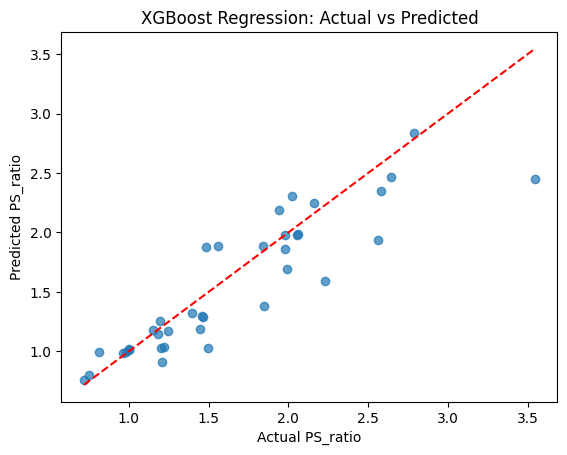

In an ideal case scenario, the points should lie on the red dotted 45 degree line/ Deviation of points from this line visually indicates how far are predicted values from actual values


In [29]:
y_pred = xgb_reg.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual PS_ratio")
plt.ylabel("Predicted PS_ratio")
plt.title("XGBoost Regression: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 45-degree line
plt.show()
print("In an ideal case scenario, the points should lie on the red dotted 45 degree line/ Deviation of points from this line visually indicates how far are predicted values from actual values")

### K-fold cross validation on XGBRegressor including wthe whole dataset 

In [30]:
# Run cross-validation
cv = cross_validate(xgb_reg, X, y, cv=kf, scoring=scoring, return_train_score=False)

# Print results
print("k-Fold CV Results (mean ± std)")
print("MAE: ", (-cv["test_mae"]).mean(), "±", (-cv["test_mae"]).std())
print("RMSE:", (-cv["test_rmse"]).mean(), "±", (-cv["test_rmse"]).std())

k-Fold CV Results (mean ± std)
MAE:  0.1881675074801447 ± 0.0162464491953412
RMSE: 0.2654577795796086 ± 0.028204800862202027


### Importance scores of Features by XGBRegressor

In [31]:
importances = xgb_reg.feature_importances_

feature_names = X.columns

sorted_idx = np.argsort(importances)[::-1]

for i in sorted_idx:

    print(f"{feature_names[i]}: {importances[i]:.3f}")

C18concentration_ug_vial: 0.611
C16concentration_ug_vial: 0.360
C34concentration_ug_vial: 0.020
FAMEconcentration: 0.009
C16conc_ug_vial: 0.000
C18conc_ug_vial: 0.000


### Permutation Importance (shuffling features and seeing how much it hurts the model)


In [32]:
perm_importance = permutation_importance(xgb_reg, X_test, y_test, n_repeats=10, random_state=0)

sorted_idx = perm_importance.importances_mean.argsort()[::-1]

for i in sorted_idx:

    print(f"{X.columns[i]}: {perm_importance.importances_mean[i]:.3f}")

C18concentration_ug_vial: 2.676
C16concentration_ug_vial: 1.178
FAMEconcentration: 0.011
C18conc_ug_vial: 0.000
C16conc_ug_vial: 0.000
C34concentration_ug_vial: -0.003


### K-Means Clustering

In [33]:
FinalDataFrameForML['target'].value_counts()

target
nr    52
p     27
r     24
d     18
Name: count, dtype: int64

In [34]:
FinalDataFrameForML

,C16concentration_ug_vial,C18concentration_ug_vial,C34concentration_ug_vial,FAMEconcentration,C16conc_ug_vial,C18conc_ug_vial,PS_ratio,Cholesterol_derivatives,longchain_ Alkanes,Alcohols,Sulphur,target
0,5.276055,2.236603,6.380712,1.584887,5.276055,2.236603,2.358959,False,False,False,False,p
1,5.914593,3.251575,5.588366,2.051386,5.914593,3.251575,1.818993,False,False,False,False,nr
2,3.682827,3.191835,6.139500,1.191840,3.682827,3.191835,1.153828,False,False,False,False,r
3,5.361691,3.607618,6.350696,1.615920,5.361691,3.607618,1.486213,False,False,False,False,nr
4,3.975178,3.640587,4.422916,0.999234,3.975178,3.640587,1.091906,False,False,False,False,r
...,...,...,...,...,...,...,...,...,...,...,...,...
116,2.389047,1.030552,7.277280,0.598009,2.389047,1.030552,2.318221,False,True,True,False,p
117,1.677165,2.096592,5.918140,3.466039,1.677165,2.096592,0.799948,False,True,False,False,d
118,1.949935,1.567359,8.427425,0.996347,1.949935,1.567359,1.244090,False,False,False,False,nr
119,4.461765,3.886842,8.205607,1.596057,4.461765,3.886842,1.147915,False,True,False,False,r


Confusion Matrix:
 [[ 0  7  0 11]
 [ 0 42  3  7]
 [ 0 24  0  3]
 [ 1 14  2  7]]
sum row 1:  18
sum row 2:  52
sum row 3:  27
sum row 4:  24
Confusion matrix interpretation: Each row represents the true (actual) class, and the sum of a row gives the total number of samples belonging to that class. Each column represents a cluster produced by KMeans. 
 The value in each cell shows how many samples from a given true class were assigned to a particular cluster. This allows us to see how well the clustering groups samples from the same true class together.
Purity of the clusters: 0.47107438016528924


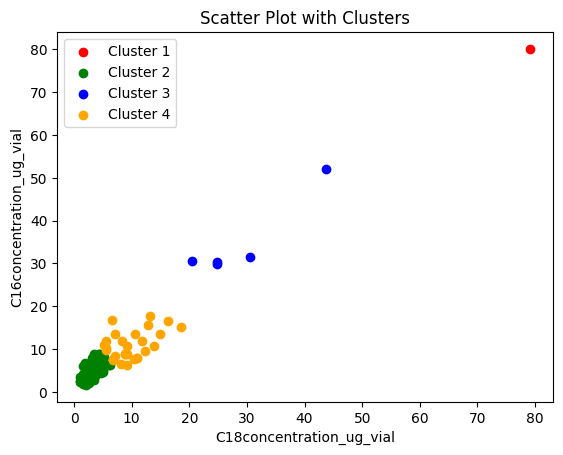

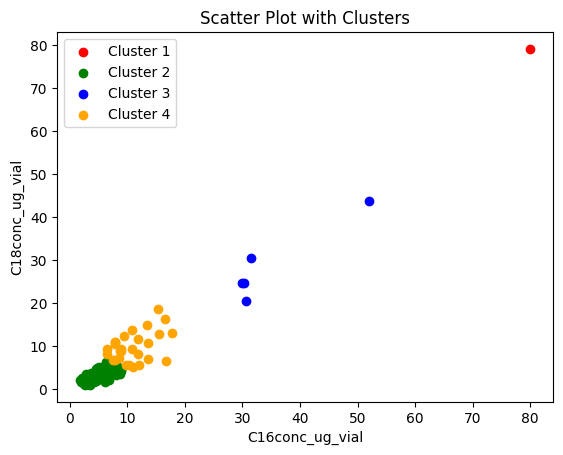

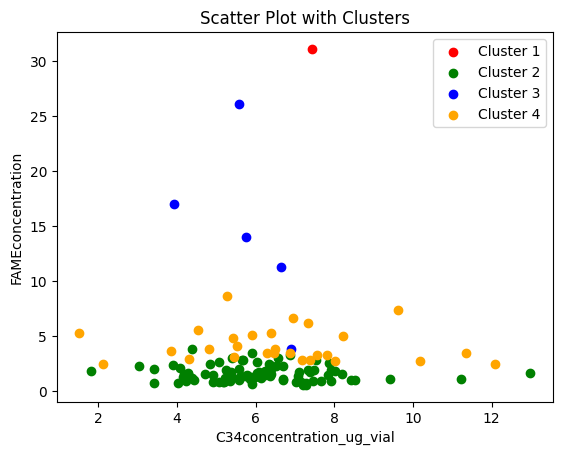

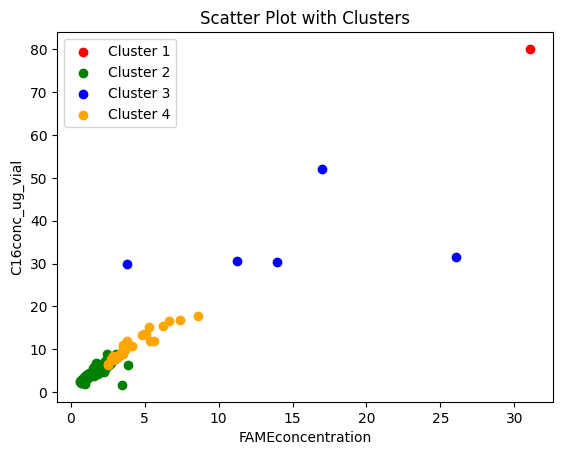

In [35]:
kmeans2 = KMeans(n_clusters=4, max_iter=100).fit(FinalDataFrameForML.drop(columns=['target','PS_ratio']))
pred2 = kmeans2.labels_

le = LabelEncoder() 
y_true = le.fit_transform(FinalDataFrameForML['target']) # turn text labels into numbers

cm = confusion_matrix(y_true, pred2) # Count how many points of true class i fall into predicted cluster j
print("Confusion Matrix:\n", cm)

print('sum row 1: ', sum(cm[0]))
print('sum row 2: ', sum(cm[1]))
print('sum row 3: ', sum(cm[2]))
print('sum row 4: ', sum(cm[3]))


print("Confusion matrix interpretation: Each row represents the true (actual) class, and the sum of a row gives the total number of samples belonging to that class. Each column represents a cluster produced by KMeans. \n The value in each cell shows how many samples from a given true class were assigned to a particular cluster. This allows us to see how well the clustering groups samples from the same true class together.")

purity = np.sum(np.max(cm, axis=0)) / np.sum(cm)
print("Purity of the clusters:", purity)

def getClusterPlots(Data, pred, Feature1, Feature2):

    X = np.array(Data)  # assuming shape (n_samples, 2)
    pred = np.array(pred)            # cluster labels

    # Define cluster names and colors
    cluster_names = {0: 'Cluster 1', 1: 'Cluster 2', 2: 'Cluster 3', 3: 'Cluster 4'}
    colors = ['red', 'green', 'blue','orange']

    # Plot each cluster separately
    for cluster_id, color in zip(cluster_names.keys(), colors):
        plt.scatter(X[pred == cluster_id, Feature1], X[pred == cluster_id, Feature2],
                    label=cluster_names[cluster_id], c=color)

    plt.xlabel(Data.columns[Feature1])
    plt.ylabel(Data.columns[Feature2])
    plt.title('Scatter Plot with Clusters')
    plt.legend()  # shows the custom legend
    plt.show()
    plt.close()
    
getClusterPlots(FinalDataFrameForML, pred2, 1, 0)
getClusterPlots(FinalDataFrameForML, pred2, 4, 5)
getClusterPlots(FinalDataFrameForML, pred2, 2, 3)
getClusterPlots(FinalDataFrameForML, pred2, 3, 4)



### k-means clustering after PCA

Original shape: (121, 11)
Reduced shape after PCA: (121, 7)

Explained variance ratio:
[0.4474317  0.12881357 0.10369551 0.09589549 0.07802222 0.07460303
 0.05972468]

Cumulative variance:
[0.4474317  0.57624526 0.67994077 0.77583626 0.85385848 0.9284615
 0.98818618]

Confusion Matrix:
 [[ 4  0  1 13]
 [22  0 18 12]
 [18  0  7  2]
 [ 5  3  4 12]]
Interpretation of confusion matrix explained in the previous k-means clustering

Purity of the clusters: 0.4628099173553719


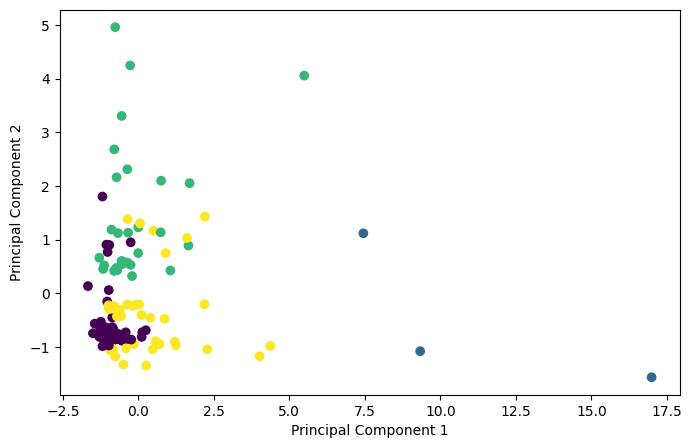

In [36]:
# Preparing the data

X = FinalDataFrameForML.drop(columns='target')
y = FinalDataFrameForML['target']


# normalization of the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



#Apply PCA to keep as mamny principle components to keep 95% variance
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X.shape)
print("Reduced shape after PCA:", X_pca.shape)

print("\nExplained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nCumulative variance:")
print(np.cumsum(pca.explained_variance_ratio_))


# K-Means Clustering

kmeans = KMeans(n_clusters=4, random_state=0)
pred = kmeans.fit_predict(X_pca)


# Confusion Matrix and Purity

le = LabelEncoder()
y_true = le.fit_transform(y)

cm = confusion_matrix(y_true, pred)

print("\nConfusion Matrix:\n", cm)
print("Interpretation of confusion matrix explained in the previous k-means clustering")
purity = np.sum(np.max(cm, axis=0)) / np.sum(cm)
print("\nPurity of the clusters:", purity)


# PCA Cluster Plot considering two principle components

plt.figure(figsize=(8,5))

scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=pred)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()


